# 32 - Metaparameters and the Wine Dataset

**Section:** Metaparameters | **Prereqs:** `Metaparameters/Normalization.ipynb` | **Next:** `Metaparameters/Activation_Functions.ipynb`

The section opener: what a metaparameter is, and a first sweep over one.

**Parameters vs metaparameters**
- **Parameters** - weights and biases. The model learns these from data by
  gradient descent. You never set them by hand.
- **Metaparameters** (hyperparameters) - learning rate, batch size, depth, width,
  activation, optimizer, dropout rate, regularisation strength. *You* set these,
  and gradient descent cannot help. Choosing them is search plus judgement, which
  is what this whole section is about.

**Also here:** a proper look at a real tabular dataset before modelling -
box plots to find outliers and scale differences, `sns.pairplot` to see which
features separate the classes, `StandardScaler` because the 11 features are on
wildly different scales, and binarising a 0-10 quality score into good/bad.

**The sweep:** batch size 2 to 512. Watch the trade-off - small batches converge
in fewer epochs but each epoch is slow; large batches are fast per epoch and need
more of them.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# https://archive.ics.uci.edu/

#Defination:
## **Parameters** are the featrues ( w & b) learnt by the model while training.

##  **Metaparameters** are the features of the model that we set like the lr, model arch.

In [ ]:
!pip install ucimlrepo

In [ ]:
# UCI wine quality: 6497 wines, 11 physicochemical features, quality 0-10.
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

cols = X.columns

In [ ]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


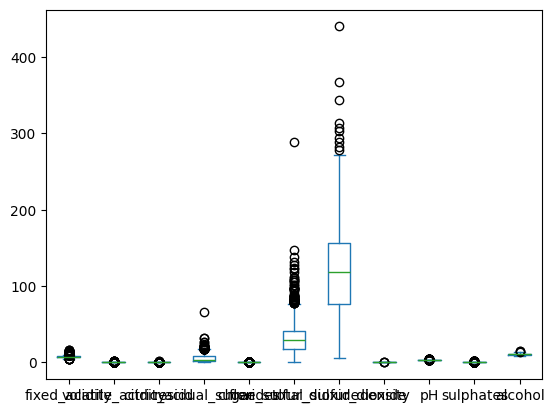

In [ ]:
# Box plots BEFORE modelling. Two things to read off: the enormous spread in
# free_sulfur_dioxide (outliers past 200) and the fact that the features live on
# completely different scales - which is why scaling is not optional here.
# X = X[X["free_sulfur_dioxide"] < 200] should do it but since the data is already divided, we won't do it here, we are removing extream outliers
X.plot.box();

In [ ]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


/tmp/ipython-input-30-1566599187.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  select_X["quality"] = y['quality']


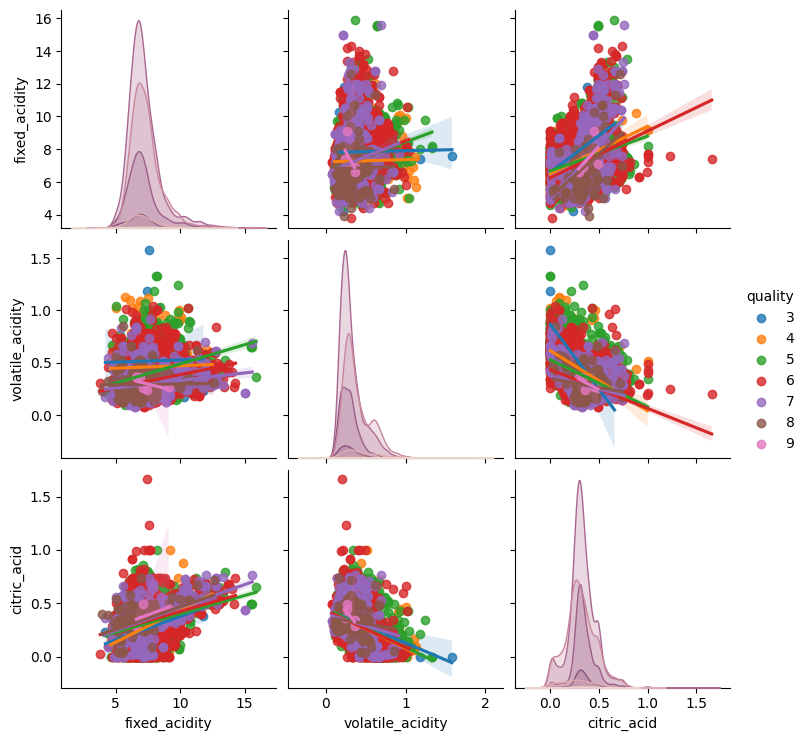

In [ ]:
# Pairwise scatter plots coloured by quality. This is how you find out whether
# any single feature separates the classes before you train anything.
select_X = X[["fixed_acidity", "volatile_acidity", "citric_acid"]]
select_X["quality"] = y['quality']
sns.pairplot(select_X, hue="quality", kind="reg", diag_kind="kde");

In [ ]:
# Z score scaling [ (x - mean) / std ], per feature.
# X_raw is kept so the MODEL's scaler can be fit on the training split alone
# (see the split cell below). What is scaled here is a display copy, used only
# for the box plot - the model never sees it.

''' Note : Its a good habit to normalize / standerdize the data after splitting it'''

X_raw = X.copy()
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X = pd.DataFrame(X, columns=(cols))

In [ ]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464
1,0.451036,3.282235,-2.192833,-0.597640,1.197975,-0.311320,-0.862469,0.701486,-0.115073,0.999579,-0.580068
2,0.451036,2.553300,-1.917553,-0.660699,1.026697,-0.874763,-1.092486,0.768188,0.258120,0.797958,-0.580068
3,3.073817,-0.362438,1.661085,-0.744778,0.541412,-0.762074,-0.986324,1.101694,-0.363868,0.327510,-0.580068
4,0.142473,2.188833,-2.192833,-0.744778,0.569958,-1.100140,-1.446359,1.034993,1.813090,0.193097,-0.915464
...,...,...,...,...,...,...,...,...,...,...,...
6492,-0.783214,-0.787650,-0.197054,-0.807837,-0.486252,-0.367664,-0.420128,-1.186161,0.320319,-0.210144,0.593818
6493,-0.474652,-0.119460,0.284686,0.537425,-0.257883,1.491697,0.924588,0.067824,-0.426067,-0.478971,-0.747766
6494,-0.551792,-0.605417,-0.885253,-0.891916,-0.429160,-0.029599,-0.083949,-0.719251,-1.421248,-0.478971,-0.915464
6495,-1.323198,-0.301694,-0.128234,-0.912936,-0.971538,-0.593041,-0.101642,-2.003251,0.755710,-1.016626,1.935402


/tmp/ipython-input-34-525935092.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(X, labels=cols)


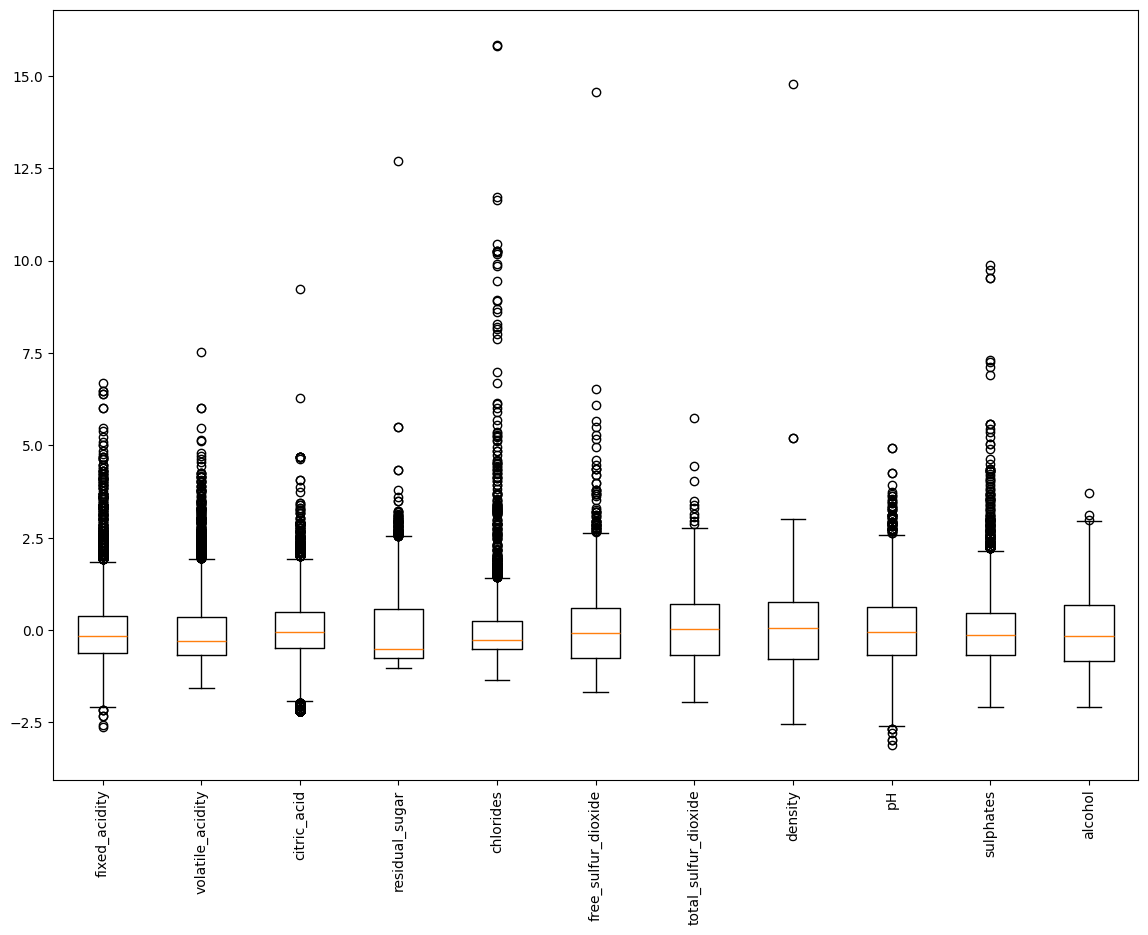

In [ ]:
# Box plots after scaling: every feature now centred on 0 with comparable
# spread. Compare with the first box plot - this is what the model should see.
fig, ax = plt.subplots(figsize = (14,10))
ax.boxplot(X, labels=cols)
plt.xticks(rotation=90);

In [ ]:
# Binarise quality: > 5 is 'good'. The threshold is a modelling CHOICE, and
# moving it changes the class balance (see More on Data/CodeChallenge_UnbalancedData).
# Binarizing the targets

y['Bool Quality'] = y > 5

/tmp/ipython-input-35-2592541463.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y > 5


In [ ]:
y['Bool Quality'] = y['Bool Quality'].astype(int)

/tmp/ipython-input-36-10765186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y['Bool Quality'].astype(int)


In [ ]:
y = y.drop('quality', axis=1)


In [ ]:
y

,Bool Quality
0,0
1,0
2,0
3,1
4,0
...,...
6492,1
6493,0
6494,1
6495,1


In [ ]:
# Split the RAW features, then fit the scaler on the training half and apply it
# to both. This is the order that keeps test statistics out of the pipeline.
# Labels are float because BCEWithLogitsLoss needs float targets shaped like the
# output.
model_scaler = StandardScaler()
X_train, X_test, Y_train, Y_test = train_test_split(X_raw.to_numpy(), y.to_numpy(), test_size=0.20)

X_train = torch.tensor(model_scaler.fit_transform(X_train), dtype=torch.float, device="cuda")
X_test  = torch.tensor(model_scaler.transform(X_test),      dtype=torch.float, device="cuda")
Y_train = torch.tensor(Y_train, dtype=torch.float, device="cuda")
Y_test  = torch.tensor(Y_test,  dtype=torch.float, device="cuda")

train_data = TensorDataset(X_train, Y_train)
test_data = TensorDataset(X_test,Y_test)



In [ ]:
# 11 -> 128 -> 128 -> 1, raw logit out.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(11,128)

    self.hidden_layer = nn.Linear(128,128)

    self.output_layer = nn.Linear(128,1)

  def forward(self, x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.hidden_layer(x))

    x = self.output_layer(x)

    return x


In [ ]:
# Training function parameterised by batch size - the loaders are rebuilt inside
# so each run gets its own batching, with everything else identical.
def train_model(bs):

  train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, drop_last=True)
  test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

  WineClassifier = model()
  WineClassifier.to('cuda')

  lr = 0.01
  optimizer = torch.optim.SGD(WineClassifier.parameters(), lr=lr)
  lossFunc = nn.BCEWithLogitsLoss()
  epochs = 1000


  # trainig the model
  losses = torch.zeros(epochs)
  test_acc = []
  train_acc = []

  for i in range(epochs):

    WineClassifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = WineClassifier.forward(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean(((yhat > 0) == y).float()).cpu())

    losses[i] = np.mean(batch_loss)
    if(i % 100 == 0):
      print(f'BS: {bs} Losses at {i} : {losses[i]}')
    train_acc.append(np.mean(batch_acc))

    WineClassifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = WineClassifier.forward(X)
      test_acc.append(100 * torch.mean(((preds > 0) == Y ).float()).cpu())
  print()
  return losses, train_acc, test_acc

In [ ]:
# The sweep: batch sizes 2 to 512, doubling each time.
bs = [2,8,16,32,64,128,256,512]

final_losses = []
final_test_acc = []
final_train_acc = []

for i in bs:
  losses, trainAcc, testAcc = train_model(int(i))

  final_losses.append(losses)
  final_test_acc.append(testAcc)
  final_train_acc.append(trainAcc)


BS: 2 Losses at 0 : 0.5379446744918823
BS: 2 Losses at 100 : 0.20287290215492249
BS: 2 Losses at 200 : 0.08735999464988708
BS: 2 Losses at 300 : 0.06333858519792557
BS: 2 Losses at 400 : 0.03976624459028244
BS: 2 Losses at 500 : 0.02188807725906372
BS: 2 Losses at 600 : 0.017363356426358223
BS: 2 Losses at 700 : 0.007588109467178583
BS: 2 Losses at 800 : 0.006785677280277014
BS: 2 Losses at 900 : 0.0048042722046375275

BS: 8 Losses at 0 : 0.6036248803138733
BS: 8 Losses at 100 : 0.34574782848358154
BS: 8 Losses at 200 : 0.21154449880123138
BS: 8 Losses at 300 : 0.13221727311611176
BS: 8 Losses at 400 : 0.06471645087003708
BS: 8 Losses at 500 : 0.05311558023095131
BS: 8 Losses at 600 : 0.041026026010513306
BS: 8 Losses at 700 : 0.042046546936035156
BS: 8 Losses at 800 : 0.022718802094459534
BS: 8 Losses at 900 : 0.027309799566864967

BS: 16 Losses at 0 : 0.6280213594436646
BS: 16 Losses at 100 : 0.4005036950111389
BS: 16 Losses at 200 : 0.3098127245903015
BS: 16 Losses at 300 : 0.234393

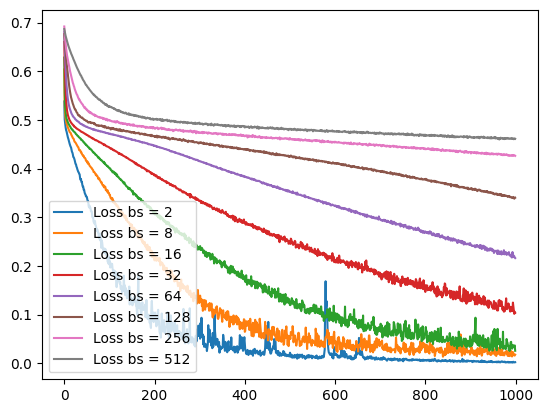

In [ ]:
# Loss curves per batch size. Small batches make many more updates per epoch, so
# they fall faster on this x-axis - which is epochs, not gradient steps.
fig, ax = plt.subplots()

for i in range(8):
  ax.plot(final_losses[i].detach(), label = f'Loss bs = {bs[i]}')
  ax.legend()




In [ ]:
# Collect the final accuracies for the summary plot.
finalAcc = []
finalTestAcc = []

for i in range(8):
  finalTestAcc.append(final_test_acc[i][-1])



for i in range(8):
   finalAcc.append(final_train_acc[i][-1])


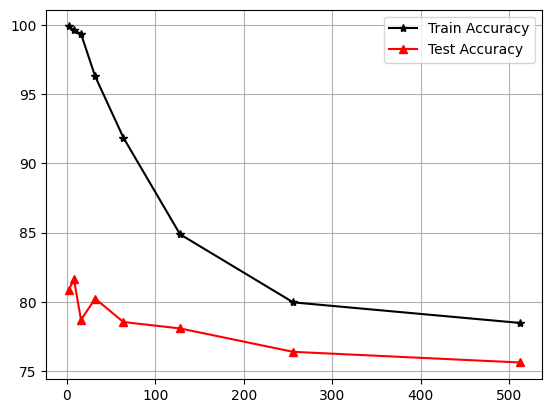

In [ ]:
# Final train and test accuracy vs batch size. Usually a shallow curve: batch
# size mostly buys speed, not accuracy. The right choice is the largest batch
# that still fits in memory and still trains - then re-tune the learning rate.
plt.plot(bs, finalAcc, "k*-", label="Train Accuracy")
plt.plot(bs, finalTestAcc, "r^-", label="Test Accuracy")
plt.grid()
plt.legend();